In [45]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Input,Dropout
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np


In [19]:
data = mnist.load_data()

In [20]:
(x_train,y_train), (x_test,y_test) = data

print("X_train",x_train.shape)
print("Y_train",y_train.shape)
print("X_test",x_test.shape)
print("y_test",y_test.shape)

X_train (60000, 28, 28)
Y_train (60000,)
X_test (10000, 28, 28)
y_test (10000,)


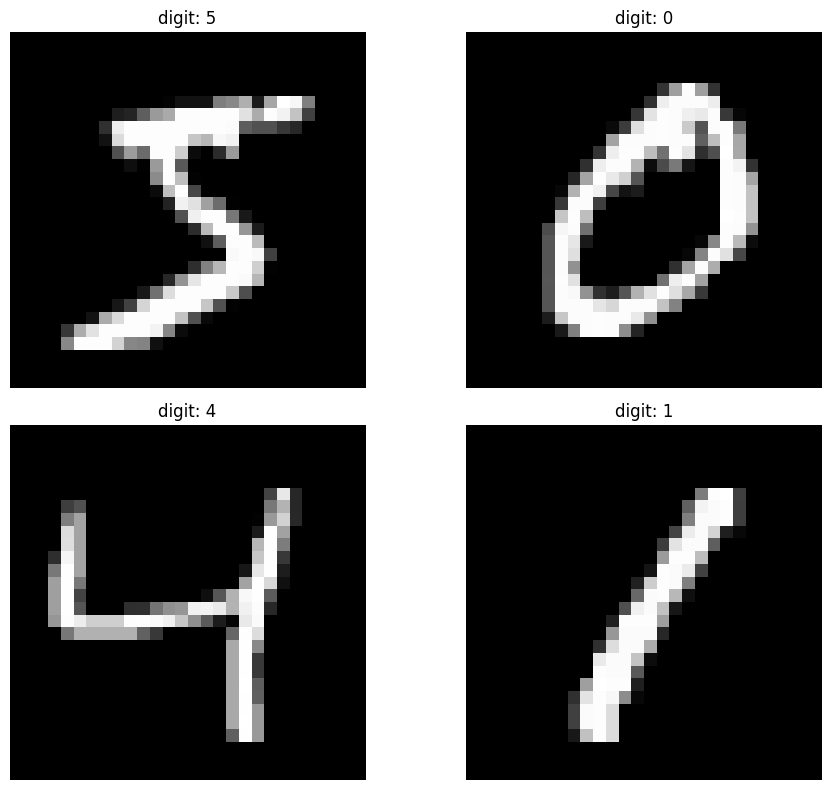

In [21]:
plt.figure(figsize=(10,8))

for i in range(4):
  plt.subplot(2,2,i+1)
  plt.imshow(x_train[i],cmap="grey")
  plt.title(f"digit: {y_train[i]}")
  plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
x_train = x_train.astype("float32")/255.0
x_test = x_test.astype("float32")/255.0

print("Minimun: ",x_train.min())
print("Maximum: ",x_train.max())

Minimun:  0.0
Maximum:  1.0


In [23]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

In [24]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics = ["accuracy"]
              )

In [25]:
model_history = model.fit(x_train,y_train,
                          epochs=25,
                          batch_size=50,
                          validation_split=0.2)

Epoch 1/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9165 - loss: 0.2868 - val_accuracy: 0.9555 - val_loss: 0.1534
Epoch 2/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9639 - loss: 0.1203 - val_accuracy: 0.9672 - val_loss: 0.1194
Epoch 3/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9756 - loss: 0.0811 - val_accuracy: 0.9692 - val_loss: 0.1012
Epoch 4/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9809 - loss: 0.0594 - val_accuracy: 0.9695 - val_loss: 0.1032
Epoch 5/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9849 - loss: 0.0488 - val_accuracy: 0.9712 - val_loss: 0.0966
Epoch 6/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9883 - loss: 0.0370 - val_accuracy: 0.9708 - val_loss: 0.1017
Epoch 7/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9903 - loss: 0.0291 - val_accuracy: 0.9728 - val_loss: 0.1000
Epoch 8/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9918 - loss: 0.0246 - val_accuracy: 0.

In [26]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9748 - loss: 0.1477
Test Accuracy: 97.48%


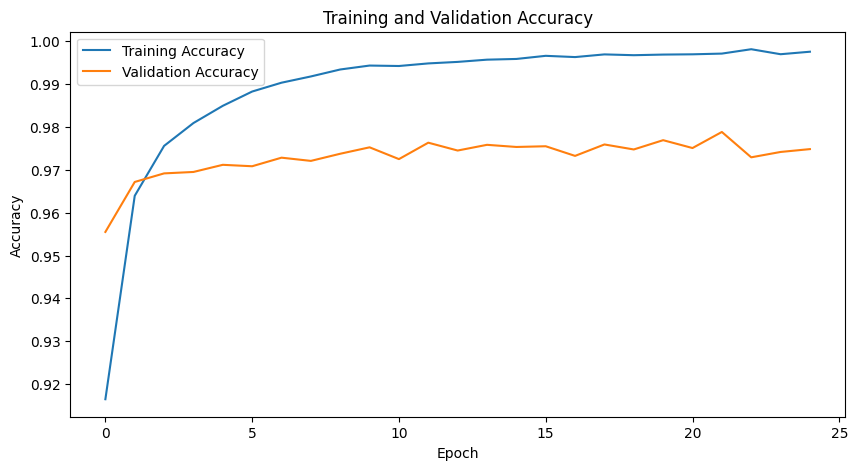

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(model_history.history["accuracy"], label="Training Accuracy")
plt.plot(model_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

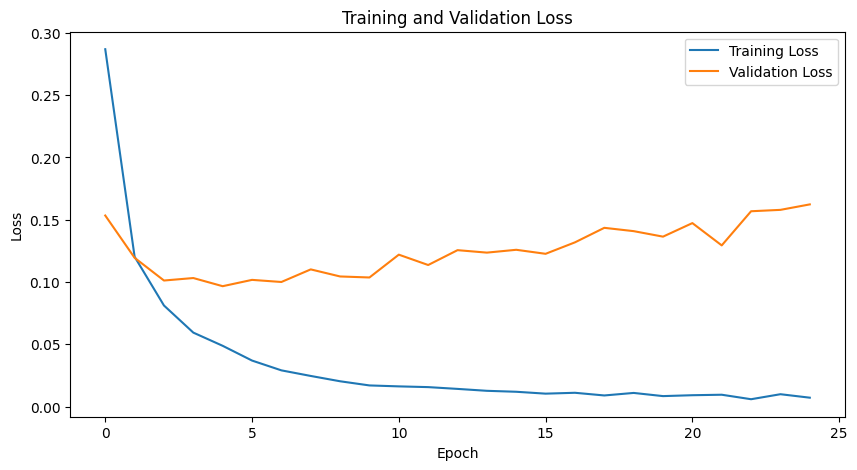

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(model_history.history["loss"], label="Training Loss")
plt.plot(model_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [29]:
dropout_model = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(10, activation="softmax")
    ])

In [30]:
dropout_model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics = ["accuracy"]
              )

In [31]:
history_dropout = dropout_model.fit(x_train,y_train,
                          epochs=10,
                          batch_size=50,
                          validation_split=0.2)

Epoch 1/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8897 - loss: 0.3639 - val_accuracy: 0.9578 - val_loss: 0.1469
Epoch 2/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9510 - loss: 0.1628 - val_accuracy: 0.9681 - val_loss: 0.1084
Epoch 3/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9623 - loss: 0.1256 - val_accuracy: 0.9702 - val_loss: 0.1027
Epoch 4/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9687 - loss: 0.1039 - val_accuracy: 0.9709 - val_loss: 0.0913
Epoch 5/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9729 - loss: 0.0872 - val_accuracy: 0.9752 - val_loss: 0.0866
Epoch 6/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9753 - loss: 0.0786 - val_accuracy: 0.9748 - val_loss: 0.0870
Epoch 7/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9771 - loss: 0.0727 - val_accuracy: 0.9747 - val_loss: 0.0880
Epoch 8/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9790 - loss: 0.0634 - val_accuracy: 0

In [32]:
test_loss_do, test_acc_do = dropout_model.evaluate(x_test, y_test, verbose=1)
print(f"Dropout Model Test Accuracy: {test_acc_do * 100:.2f}%")
print(f"Dropout Model Test Loss: {test_loss_do:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9800 - loss: 0.0707
Dropout Model Test Accuracy: 98.00%
Dropout Model Test Loss: 0.0707


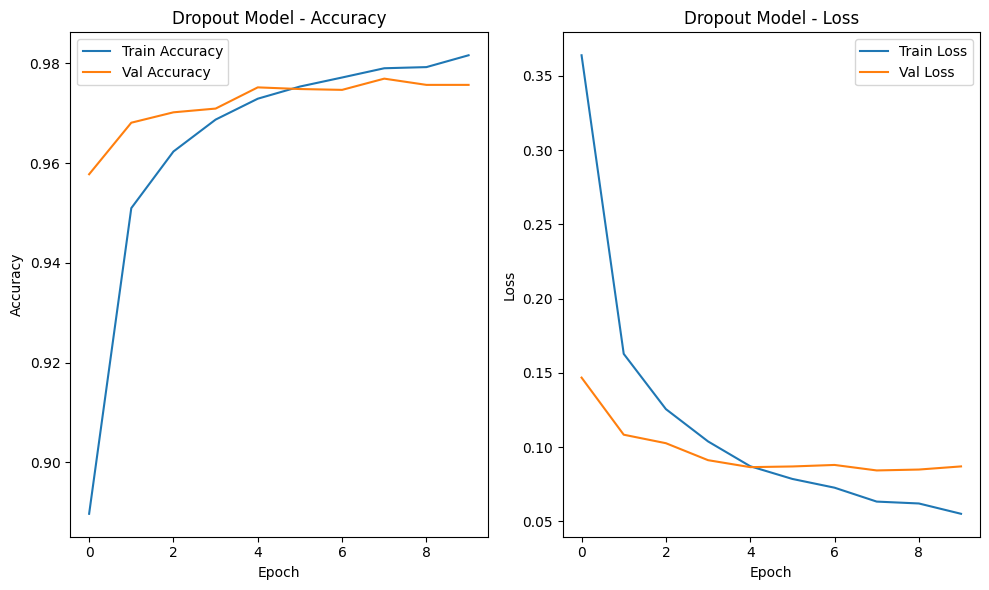

In [38]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.plot(history_dropout.history["accuracy"], label="Train Accuracy")
plt.plot(history_dropout.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Dropout Model - Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dropout.history["loss"], label="Train Loss")
plt.plot(history_dropout.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dropout Model - Loss")
plt.legend()

plt.tight_layout()
plt.show()

Comparison of normal and dropout model


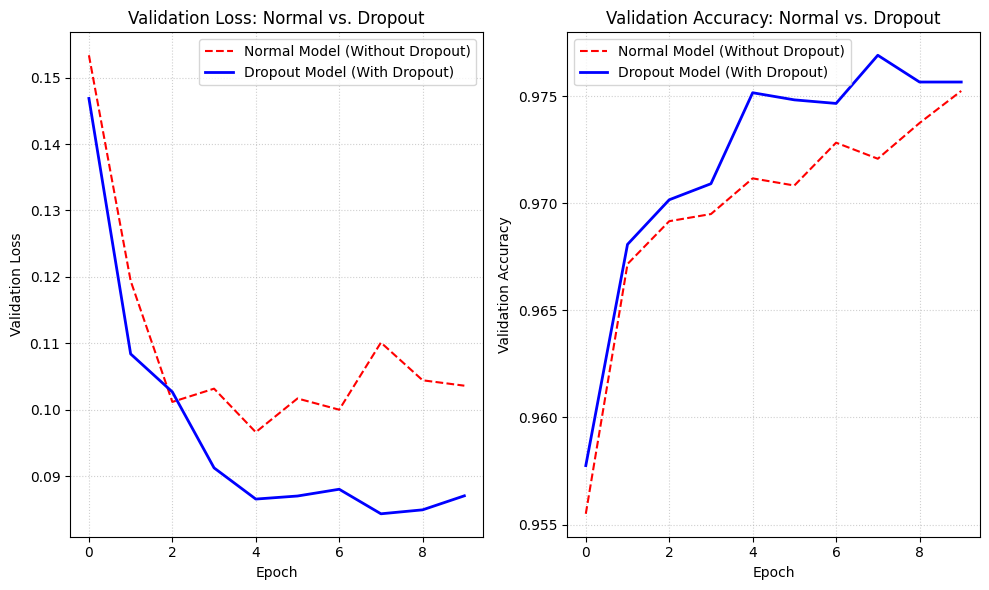

In [41]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(model_history.history["val_loss"][:10], label="Normal Model (Without Dropout)", color="red", linestyle="--")
plt.plot(history_dropout.history["val_loss"], label="Dropout Model (With Dropout)", color="blue", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Normal vs. Dropout")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

    # 2. Validation Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(model_history.history["val_accuracy"][:10], label="Normal Model (Without Dropout)", color="red", linestyle="--")
plt.plot(history_dropout.history["val_accuracy"], label="Dropout Model (With Dropout)", color="blue", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: Normal vs. Dropout")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [42]:
test_loss_do, test_acc_do = dropout_model.evaluate(x_test, y_test, verbose=1)

print("\n--- Final Test Comparison ---")
print(f"Normal Model  -> Loss: {test_loss:.4f} | Accuracy: {test_accuracy * 100:.2f}%")
print(f"Dropout Model -> Loss: {test_loss_do:.4f} | Accuracy: {test_acc_do * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9800 - loss: 0.0707

--- Final Test Comparison ---
Normal Model  -> Loss: 0.1477 | Accuracy: 97.48%
Dropout Model -> Loss: 0.0707 | Accuracy: 98.00%


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.96      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.97      0.98      0.97       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



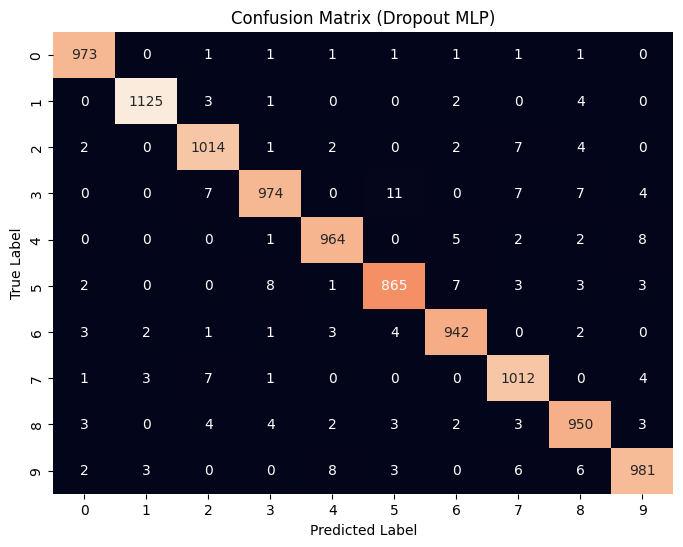

In [58]:
y_pred_probs = dropout_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

    # Precision, recall, and F1-score for each digit (0-9)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

    # Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Dropout MLP)")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


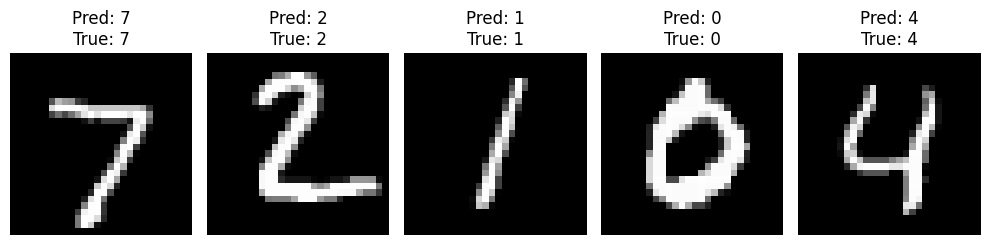

In [61]:
predictions = dropout_model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 3))
for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(x_test[i], cmap="gray")
        plt.title(f"Pred: {predicted_labels[i]}\nTrue: {y_test[i]}")
        plt.axis("off")

plt.tight_layout()
plt.show()